In [1]:
# Regular EDA and plotting libraries
import numpy as np  #tableaux et matrices
import pandas as pd # Permet de manipuler et d'analyser des données sous forme de dataframes, ce qui est similaire à des tableaux Excel
import matplotlib.pyplot as plt  #Permet de créer des visualisations de données, comme des graphiques et des diagrammes.
import seaborn as sns #  Permet de créer des visualisations de données plus complexes et plus attrayantes que celles fournies par matplotlib.

# We want our plots to appear in the notebook
# Afin de visualiser les graphiques dans le notebook
%matplotlib inline 


# Importation des métriques
from sklearn.metrics import accuracy_score


## Models
from sklearn.linear_model import LogisticRegression #implémenter le modèle de régression logistique
from sklearn.neighbors import KNeighborsClassifier # pour implémenter le modèle de plus proches voisins (KNN)
from sklearn.ensemble import RandomForestClassifier #implémenter le modèle de forêt d'arbres aléatoires (Random Forest)
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

## Model evaluators
from sklearn.model_selection import train_test_split, cross_val_score #utilisés pour diviser les données en ensembles d'entraînement et de test, et pour évaluer les modèles à l'aide de la validation croisée.
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV #pour ajuster les hyperparamètres des modèles.
from sklearn.metrics import confusion_matrix, classification_report # pour évaluer les performances des modèles de classification.
from sklearn.metrics import precision_score, recall_score, f1_score #pour évaluer les performances des modèles de classification.
from sklearn.metrics import RocCurveDisplay # new in Scikit-Learn 1.2+( utilisez une version antérieure de Scikit-Learn) #utilisé pour afficher la courbe ROC des modèles de classification.

# Print last updated
import time
print(f"Last updated: {time.asctime()}")

Last updated: Sat Apr 11 10:22:59 2026


In [10]:
df = pd.read_csv("heart_disease_dataset1.csv") # 'DataFrame' shortened to 'df'  # charger le jeu de données 
df.shape # (rows, columns)  # afficher sa taille

(1000, 16)

In [11]:
#Exploration initiale du jeu de données
df.head(10)  # Affiche les 5 premières lignes du DataFrame

,age,gender,chol,bp,hr,smoke,alcohol,exercise,family_hist,diabetes,obesity,stress,sugar,angina,cp,target
0,75,0,228,119,66,2,2.0,1,0,0,1,8,119,1,1,1
1,48,1,204,165,62,2,0.0,5,0,0,0,9,70,1,0,0
2,53,1,234,91,67,0,2.0,3,1,0,1,5,196,1,1,1
3,69,0,192,90,72,2,0.0,4,0,1,0,7,107,1,2,0
4,62,0,172,163,93,0,0.0,6,0,1,0,2,183,1,3,0
5,77,1,309,110,73,0,0.0,0,0,1,1,4,122,1,3,1
6,64,0,211,105,86,1,2.0,8,1,1,1,2,120,0,0,1
7,60,0,208,148,83,0,1.0,4,0,1,1,2,113,1,3,1
8,37,0,317,137,66,2,2.0,3,0,1,1,5,114,0,2,0
9,63,1,204,141,68,1,2.0,8,0,1,0,3,107,0,3,1


In [12]:
df.describe()  # Donne des statistiques descriptives

,age,gender,chol,bp,hr,smoke,alcohol,exercise,family_hist,diabetes,obesity,stress,sugar,angina,cp,target
count,1000.000000,1000.000000,1000.000000,1000.0000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.0000,1000.000000
mean,52.293000,0.497000,249.939000,135.2810,79.204000,0.998000,1.006000,4.529000,0.499000,0.505000,0.499000,5.646000,134.941000,0.472000,1.5020,0.392000
std,15.727126,0.500241,57.914673,26.3883,11.486092,0.821383,0.828644,2.934241,0.500249,0.500225,0.500249,2.831024,36.699624,0.499465,1.1168,0.488441
min,25.000000,0.000000,150.000000,90.0000,60.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,70.000000,0.000000,0.0000,0.000000
25%,39.000000,0.000000,200.000000,112.7500,70.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,3.000000,104.000000,0.000000,0.7500,0.000000
50%,52.000000,0.000000,248.000000,136.0000,79.000000,1.000000,1.000000,4.500000,0.000000,1.000000,0.000000,6.000000,135.000000,0.000000,2.0000,0.000000
75%,66.000000,1.000000,299.000000,159.0000,89.000000,2.000000,2.000000,7.000000,1.000000,1.000000,1.000000,8.000000,167.000000,1.000000,2.0000,1.000000
max,79.000000,1.000000,349.000000,179.0000,99.000000,2.000000,2.000000,9.000000,1.000000,1.000000,1.000000,10.000000,199.000000,1.000000,3.0000,1.000000


In [13]:
df.info()  # Affiche les informations sur les colonnes et les types de données

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          1000 non-null   int64  
 1   gender       1000 non-null   int64  
 2   chol         1000 non-null   int64  
 3   bp           1000 non-null   int64  
 4   hr           1000 non-null   int64  
 5   smoke        1000 non-null   int64  
 6   alcohol      1000 non-null   float64
 7   exercise     1000 non-null   int64  
 8   family_hist  1000 non-null   int64  
 9   diabetes     1000 non-null   int64  
 10  obesity      1000 non-null   int64  
 11  stress       1000 non-null   int64  
 12  sugar        1000 non-null   int64  
 13  angina       1000 non-null   int64  
 14  cp           1000 non-null   int64  
 15  target       1000 non-null   int64  
dtypes: float64(1), int64(15)
memory usage: 125.1 KB


In [14]:
df.dtypes  # Donne le type de données de chaque colonne

age              int64
gender           int64
chol             int64
bp               int64
hr               int64
smoke            int64
alcohol        float64
exercise         int64
family_hist      int64
diabetes         int64
obesity          int64
stress           int64
sugar            int64
angina           int64
cp               int64
target           int64
dtype: object

In [15]:
#Afficher la somme des valeurs manquantes
df.isnull().sum()

age            0
gender         0
chol           0
bp             0
hr             0
smoke          0
alcohol        0
exercise       0
family_hist    0
diabetes       0
obesity        0
stress         0
sugar          0
angina         0
cp             0
target         0
dtype: int64

In [16]:
# Vérifier les doublons
duplicate_rows = df[df.duplicated()]
print("Nombre de lignes dupliquées:", duplicate_rows.shape[0])


Nombre de lignes dupliquées: 0


In [18]:
# Let's see how many positive (1) and negative (0) samples we have in our dataframe
df.target.value_counts()  #compter le nombre d'occurrences de chaque valeur de la cible dans le jeu de données (nd de repetition de valeur de target)

target
0    608
1    392
Name: count, dtype: int64

In [19]:
# Normalized value counts
df.target.value_counts(normalize=True)  #permet d'obtenir le nombre d'occurrences de chaque valeur unique dans une série ou une colonne de données
# nb d'occurrence (target)/taille dataset

target
0    0.608
1    0.392
Name: proportion, dtype: float64

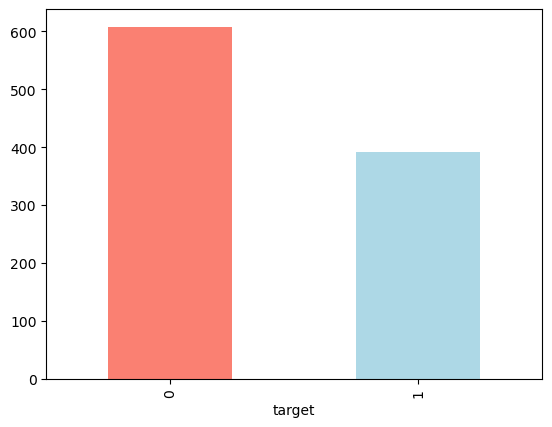

In [20]:
# Plot the value counts with a bar graph
df.target.value_counts().plot(kind="bar", color=["salmon", "lightblue"]); #Pour tracer les valeurs comptées avec un graphique en barres de la variable cible

In [22]:
df.gender.value_counts()  #Pour compter le nombre d'occurrences de chaque valeur unique de la colonne sex dans le DataFrame df

gender
0    503
1    497
Name: count, dtype: int64

In [23]:
# Compare target column with sex column
pd.crosstab(df.target, df.gender)
#gerer les des femme et homme si malade et si non
#suparer terget en homme et femme

gender,0,1
target,,
0,313,295
1,190,202


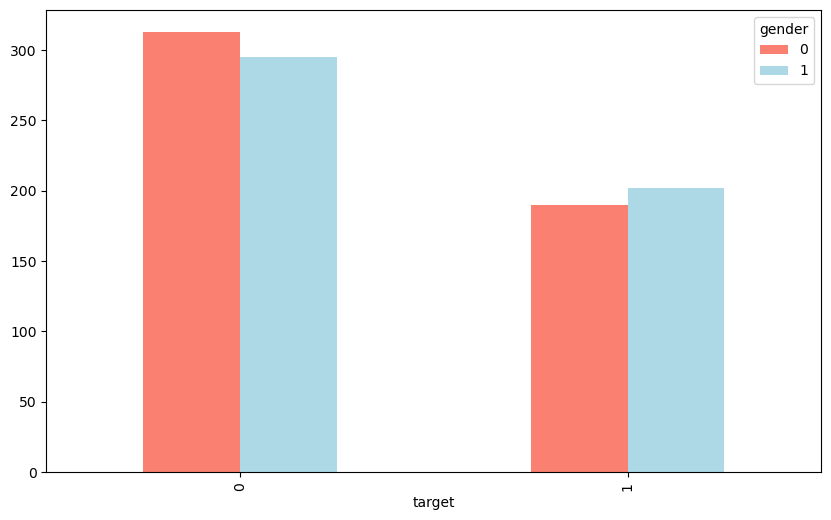

In [25]:
# Create a plot
pd.crosstab(df.target, df.gender).plot(kind="bar", 
                                    figsize=(10,6), 
                                    color=["salmon", "lightblue"]);

#tracer la separation dans un graphe

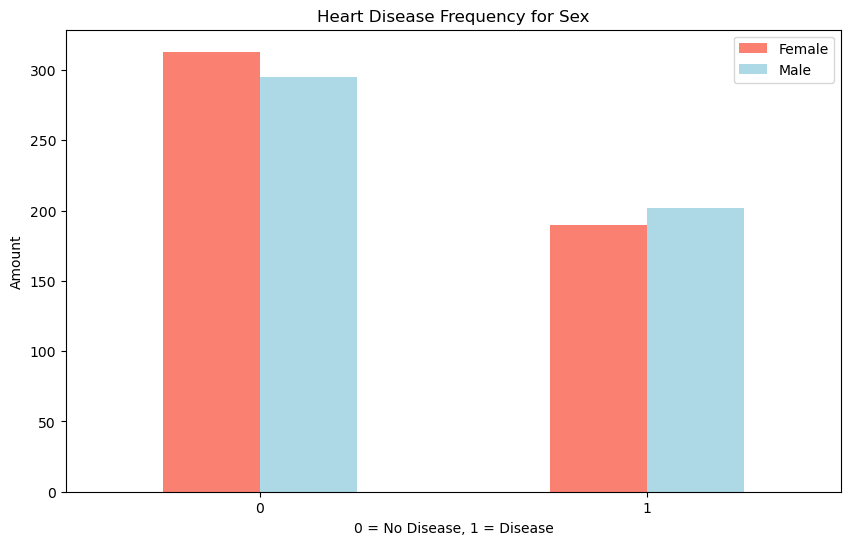

In [26]:
# Create a plot
pd.crosstab(df.target, df.gender).plot(kind="bar", figsize=(10,6), color=["salmon", "lightblue"])

# Add some attributes to it
plt.title("Heart Disease Frequency for Sex")
plt.xlabel("0 = No Disease, 1 = Disease")
plt.ylabel("Amount")
plt.legend(["Female", "Male"])
plt.xticks(rotation=0); # keep the labels on the x-axis vertical

#crée un graphique de barres montrant la fréquence des maladies cardiaques en fonction du sexe.
#tracer meme graphe avec autres parametre

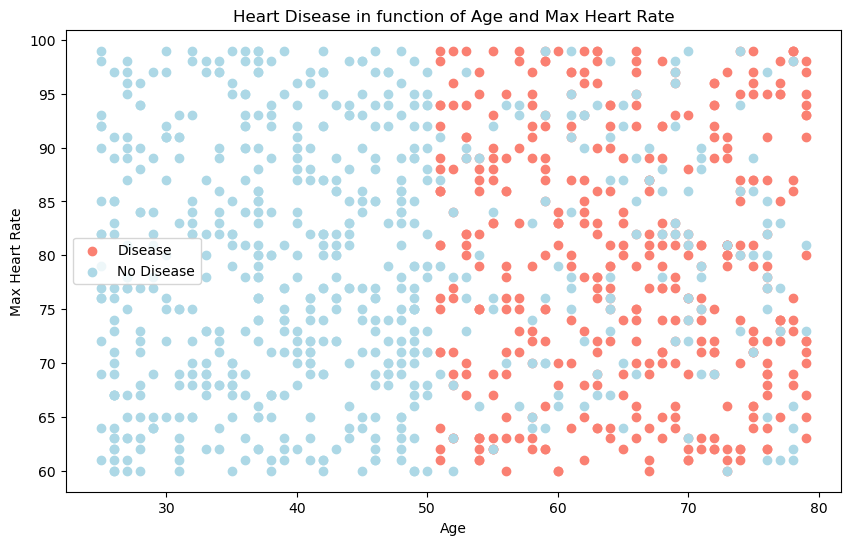

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

# Cas maladie (1)
plt.scatter(
    df.age[df.target == 1],
    df.hr[df.target == 1],
    c="salmon",
    label="Disease"
)

# Cas sans maladie (0)
plt.scatter(
    df.age[df.target == 0],
    df.hr[df.target == 0],
    c="lightblue",
    label="No Disease"
)

# Infos
plt.title("Heart Disease in function of Age and Max Heart Rate")
plt.xlabel("Age")
plt.ylabel("Max Heart Rate")
plt.legend()
plt.show()

#crée un graphique de dispersion montrant la relation entre l'âge, le rythme cardiaque maximal et la présence ou non de maladie cardiaque

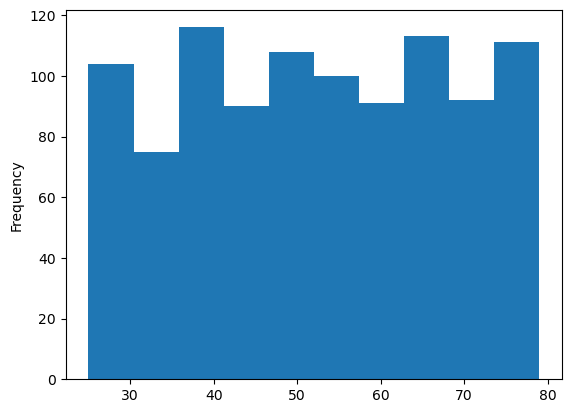

In [29]:
# Histograms are a great way to check the distribution of a variable
df.age.plot.hist();
#creer un histogramme de colonne age

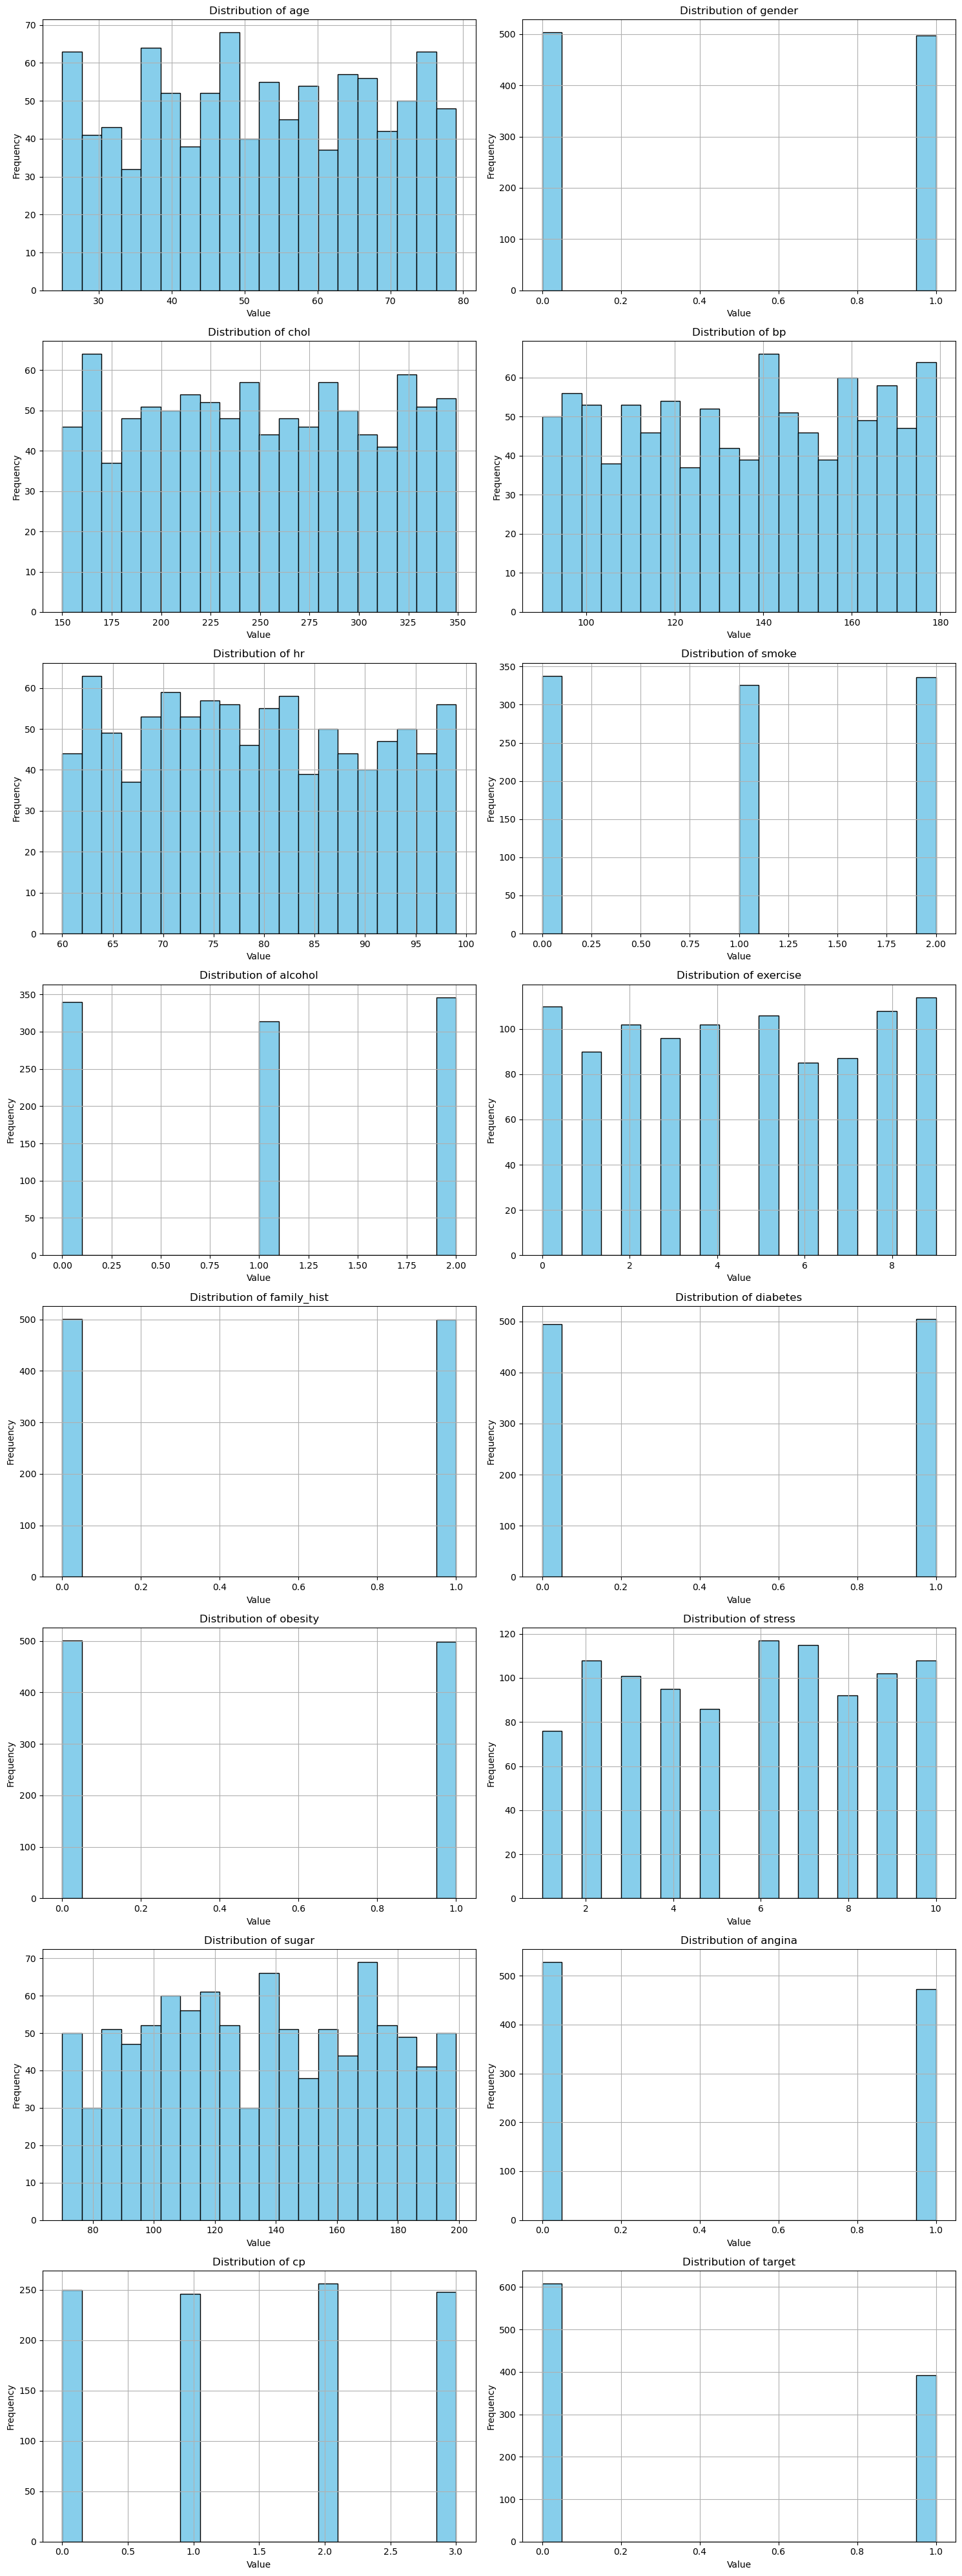

In [30]:
def plot_per_column_distribution(dataframe):
    """
    Plot distribution of each column in the dataframe.
    
    Parameters:
    - dataframe: DataFrame containing the data
    """
    # Calculating number of plots needed
    num_cols = len(dataframe.columns)
    nrows = int(np.ceil(num_cols / 2))
    ncols = 2
    
    # Creating subplot grid
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 5*nrows))
    
    # Flattening the axes array
    axes = axes.flatten()
    
    # Looping through each column and plotting its distribution
    for i, column in enumerate(dataframe.columns):
        ax = axes[i]
        ax.hist(dataframe[column], bins=20, color='skyblue', edgecolor='black')
        ax.set_title(f"Distribution of {column}")
        ax.set_xlabel("Value")
        ax.set_ylabel("Frequency")
        ax.grid(True)
        
    # Adjust layout
    plt.tight_layout()
    plt.show()

# Utilisation de la fonction pour tracer la distribution de chaque colonne
plot_per_column_distribution(df)


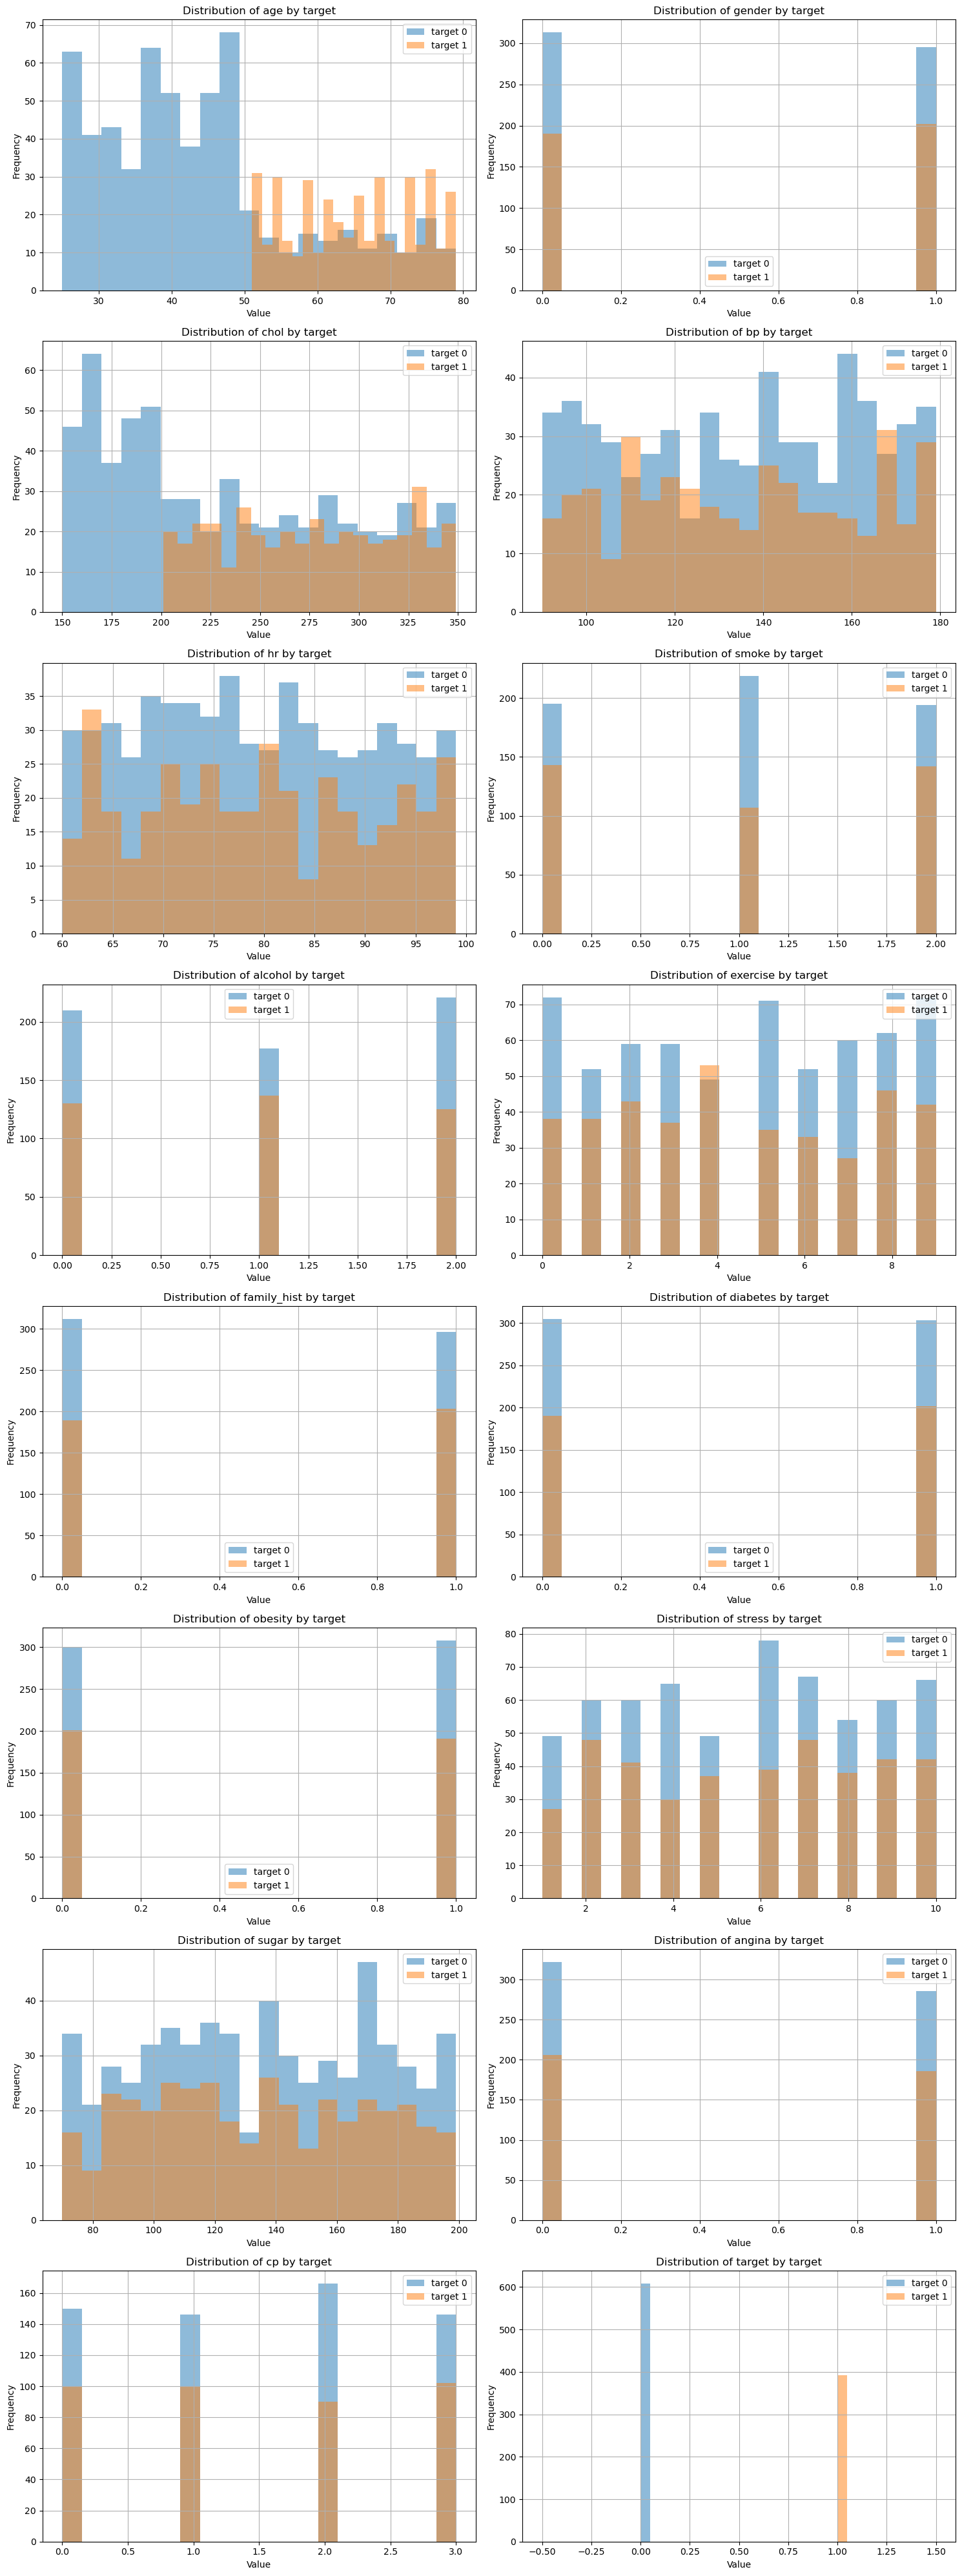

In [31]:
def plot_per_column_distribution_by_target(dataframe):
    """
    Plot distribution of each column in the dataframe grouped by 'target'.
    
    Parameters:
    - dataframe: DataFrame containing the data
    """
    # Grouping the dataframe by 'Cath'
    grouped = dataframe.groupby('target')
    
    # Calculating number of plots needed
    num_cols = len(dataframe.columns)
    nrows = int(np.ceil(num_cols / 2))
    ncols = 2
    
    # Creating subplot grid
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 5*nrows))
    
    # Flattening the axes array
    axes = axes.flatten()
    
    # Looping through each column and plotting its distribution by 'target'
    for i, column in enumerate(dataframe.columns):
        ax = axes[i]
        for group, data in grouped:
            ax.hist(data[column], bins=20, alpha=0.5, label=f'target {group}')
        ax.set_title(f"Distribution of {column} by target")
        ax.set_xlabel("Value")
        ax.set_ylabel("Frequency")
        ax.grid(True)
        ax.legend()
        
    # Adjust layout
    plt.tight_layout()
    plt.show()

# Utilisation de la fonction pour tracer la distribution de chaque colonne par rapport à 'Cath'
plot_per_column_distribution_by_target(df)


In [32]:
pd.crosstab(df.cp, df.target)

#créer un tableau de croisement entre les colonnes cp et target d'un DataFrame df
# affiche le nombre d'occurrences de chaque combinaison de valeurs entre les colonnes cp et target

target,0,1
cp,,
0,150,100
1,146,100
2,166,90
3,146,102


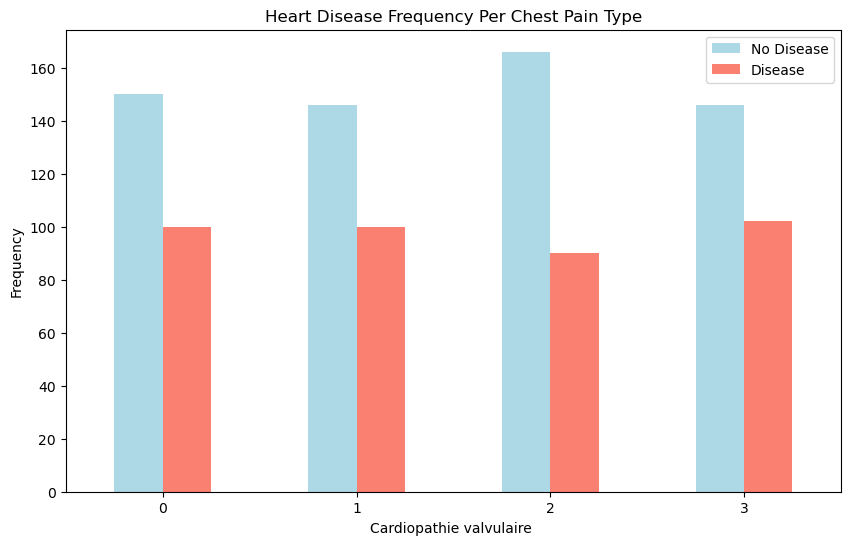

In [33]:
# Create a new crosstab and base plot
pd.crosstab(df.cp, df.target).plot(kind="bar", 
                                   figsize=(10,6), 
                                   color=["lightblue", "salmon"])

# Add attributes to the plot to make it more readable
plt.title("Heart Disease Frequency Per Chest Pain Type")
plt.xlabel("Cardiopathie valvulaire ")
plt.ylabel("Frequency")
plt.legend(["No Disease", "Disease"])
plt.xticks(rotation = 0);

#afficger resultat dans un graphe

In [34]:
# Find the correlation between our independent variables
corr_matrix = df.corr()
corr_matrix 

#calcule le coefficient de corrélation( pour déterminer la force et la direction de la relation linéaire entre deux variables) entre les variables d'un DataFrame df. 
#Le coefficient de corrélation mesure la force et la direction de la relation linéaire entre deux variables

,age,gender,chol,bp,hr,smoke,alcohol,exercise,family_hist,diabetes,obesity,stress,sugar,angina,cp,target
age,1.000000,0.014044,-0.010673,0.002093,0.029027,0.007562,-0.026788,-0.021366,0.017532,-0.011193,-0.011096,-0.045555,-0.041676,-0.022848,0.010254,0.646871
gender,0.014044,1.000000,-0.012566,-0.023785,0.014741,0.021911,0.067659,-0.024491,0.099990,-0.039943,-0.056013,0.029643,0.069209,0.005673,0.004490,0.029399
chol,-0.010673,-0.012566,1.000000,0.021841,-0.008527,-0.015490,-0.016762,0.016124,-0.007862,-0.028409,0.002814,0.090458,0.002484,0.037989,0.040326,0.365041
bp,0.002093,-0.023785,0.021841,1.000000,-0.001675,0.017021,0.017410,0.011924,-0.015410,-0.065437,-0.037476,0.002257,-0.053516,0.005496,0.005059,0.006900
hr,0.029027,0.014741,-0.008527,-0.001675,1.000000,-0.015235,0.024692,-0.013541,0.024774,0.006268,-0.039685,-0.040504,0.010240,0.005359,-0.066049,0.013209
smoke,0.007562,0.021911,-0.015490,0.017021,-0.015235,1.000000,-0.008806,0.003347,0.021920,-0.034083,0.014612,-0.017524,0.026927,-0.007457,0.000004,-0.000539
alcohol,-0.026788,0.067659,-0.016762,0.017410,0.024692,-0.008806,1.000000,-0.036712,0.016918,-0.019392,0.057970,-0.018722,0.015021,-0.043128,0.056233,-0.018183
exercise,-0.021366,-0.024491,0.016124,0.011924,-0.013541,0.003347,-0.036712,1.000000,0.029344,-0.041700,-0.006118,-0.006957,-0.034503,0.067149,-0.042630,-0.014226
family_hist,0.017532,0.099990,-0.007862,-0.015410,0.024774,0.021920,0.016918,0.029344,1.000000,0.020021,0.011996,0.047813,-0.034381,0.001891,-0.033143,0.030283
diabetes,-0.011193,-0.039943,-0.028409,-0.065437,0.006268,-0.034083,-0.019392,-0.041700,0.020021,1.000000,0.004020,-0.079329,-0.007754,-0.073559,-0.018832,0.016552


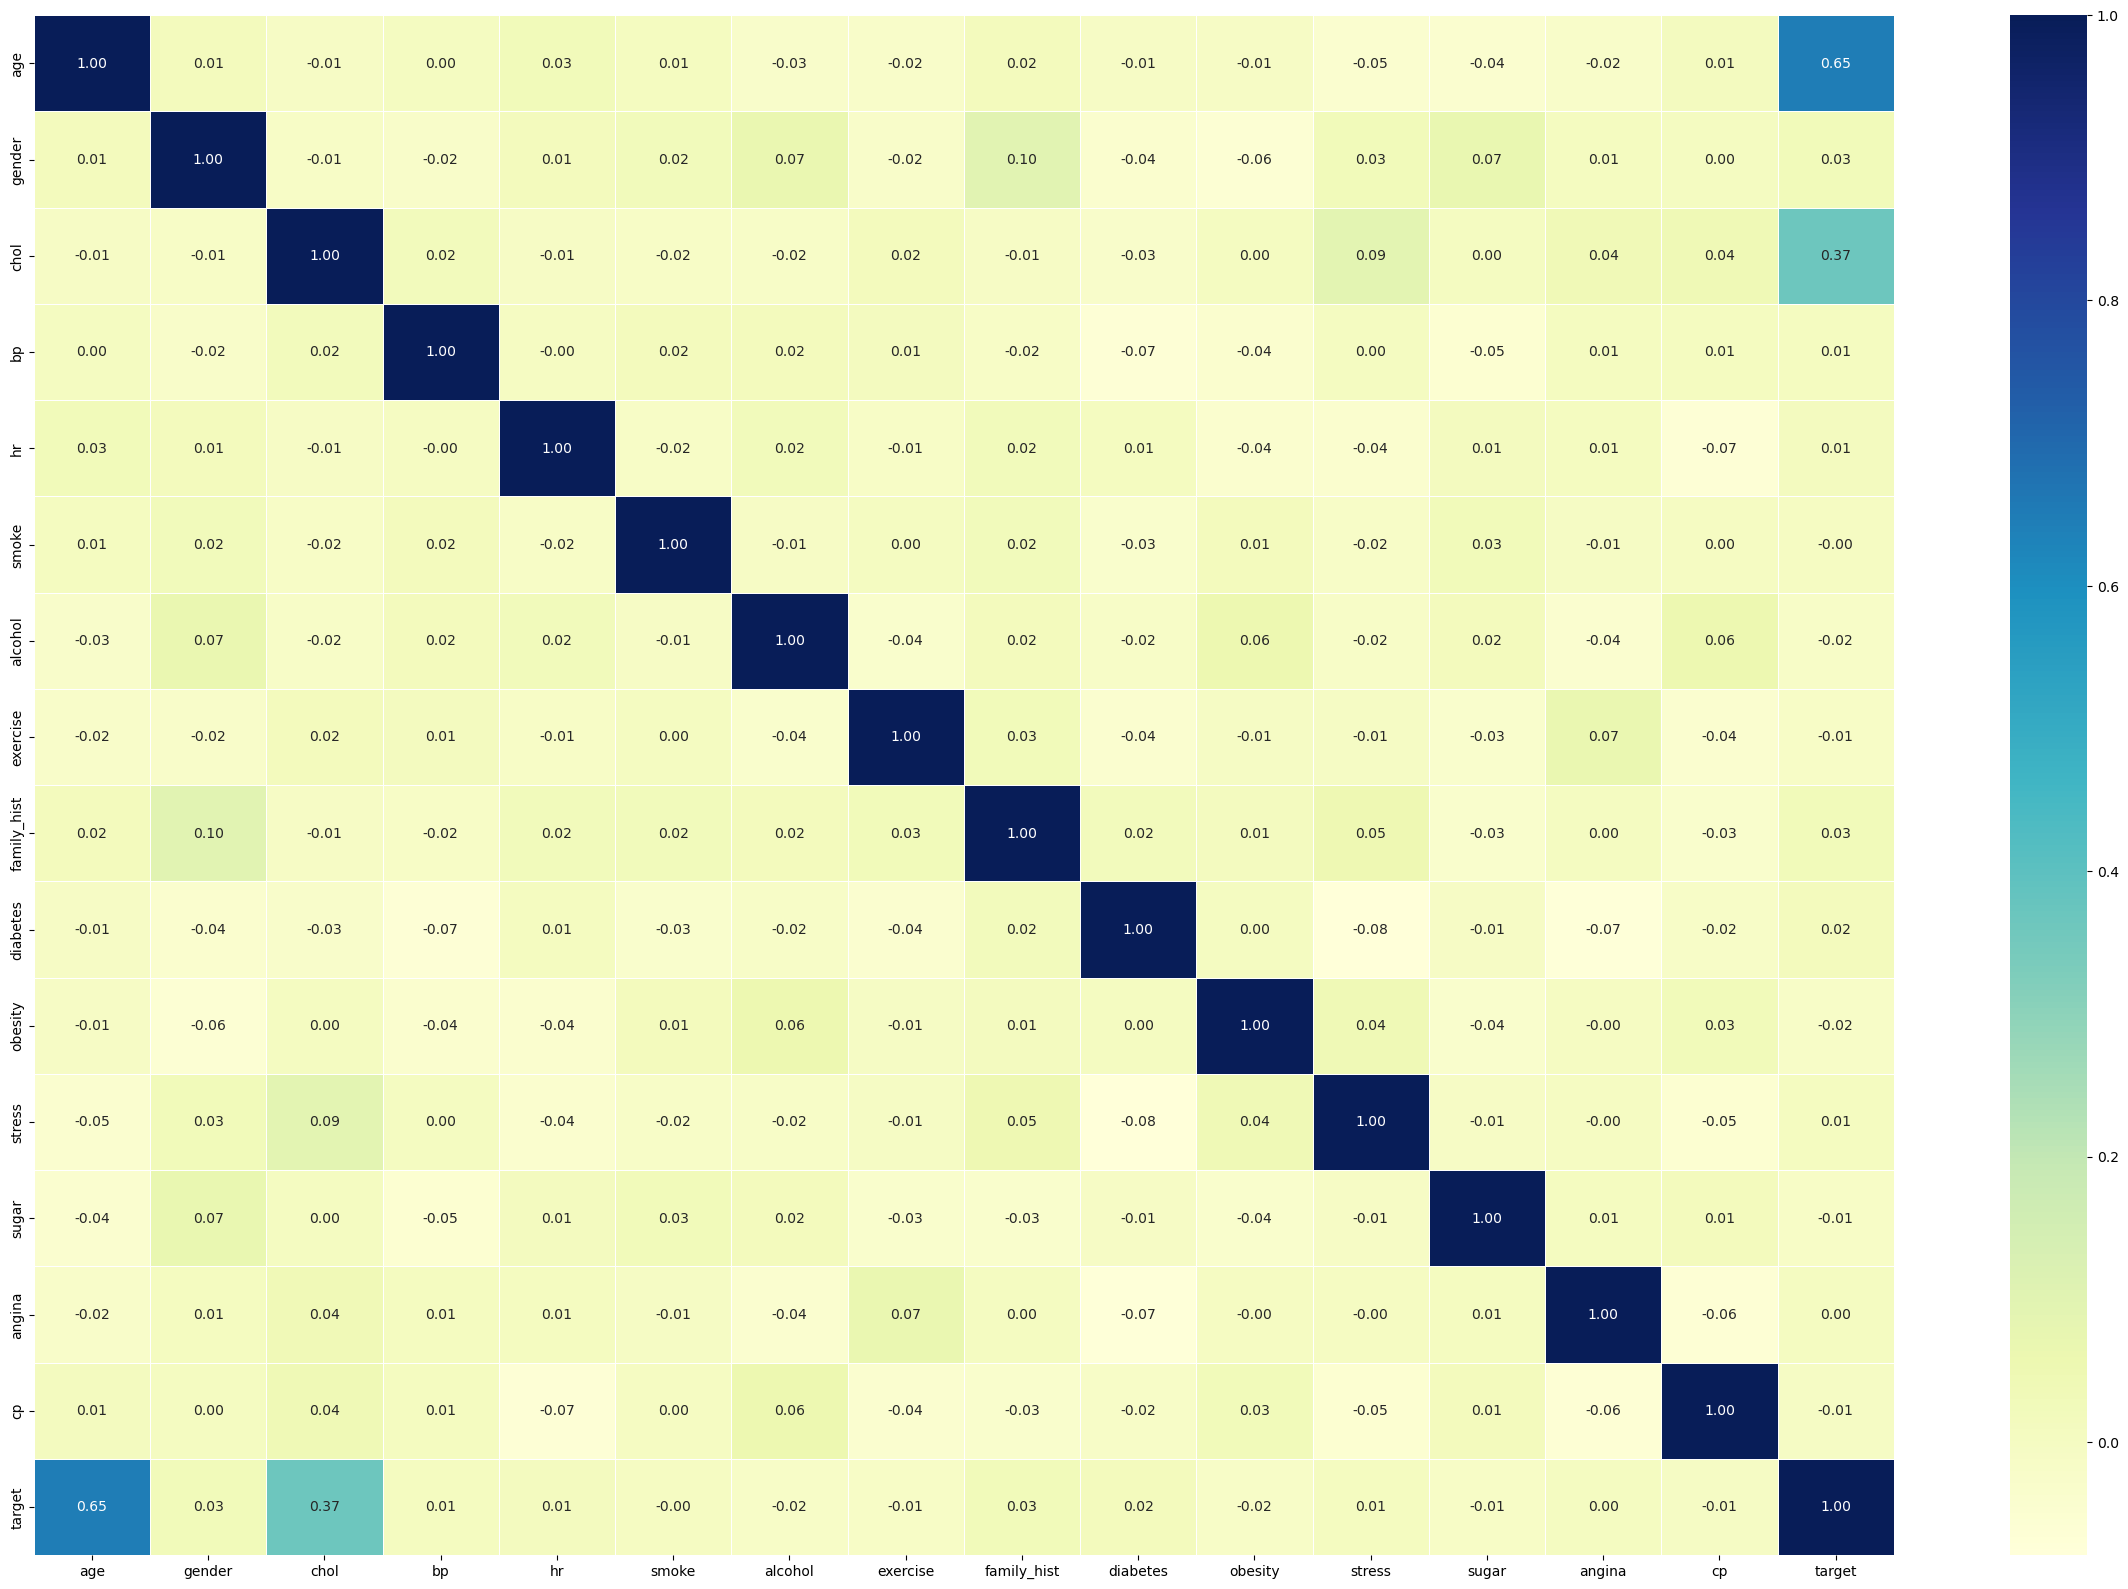

In [35]:
# Let's make it look a little prettier
corr_matrix = df.corr()
plt.figure(figsize=(30, 20))
sns.heatmap(corr_matrix, 
            annot=True, 
            linewidths=0.5, 
            fmt= ".2f", 
            cmap="YlGnBu");

#utilisé pour générer une matrice de corrélation et une carte de chaleur pour visualiser les corrélations entre les variables d'un dataframe (df)
#en utilisant la bibliothèque seaborn

C:\Users\mhbm\AppData\Local\Temp\ipykernel_5728\110917855.py:18: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


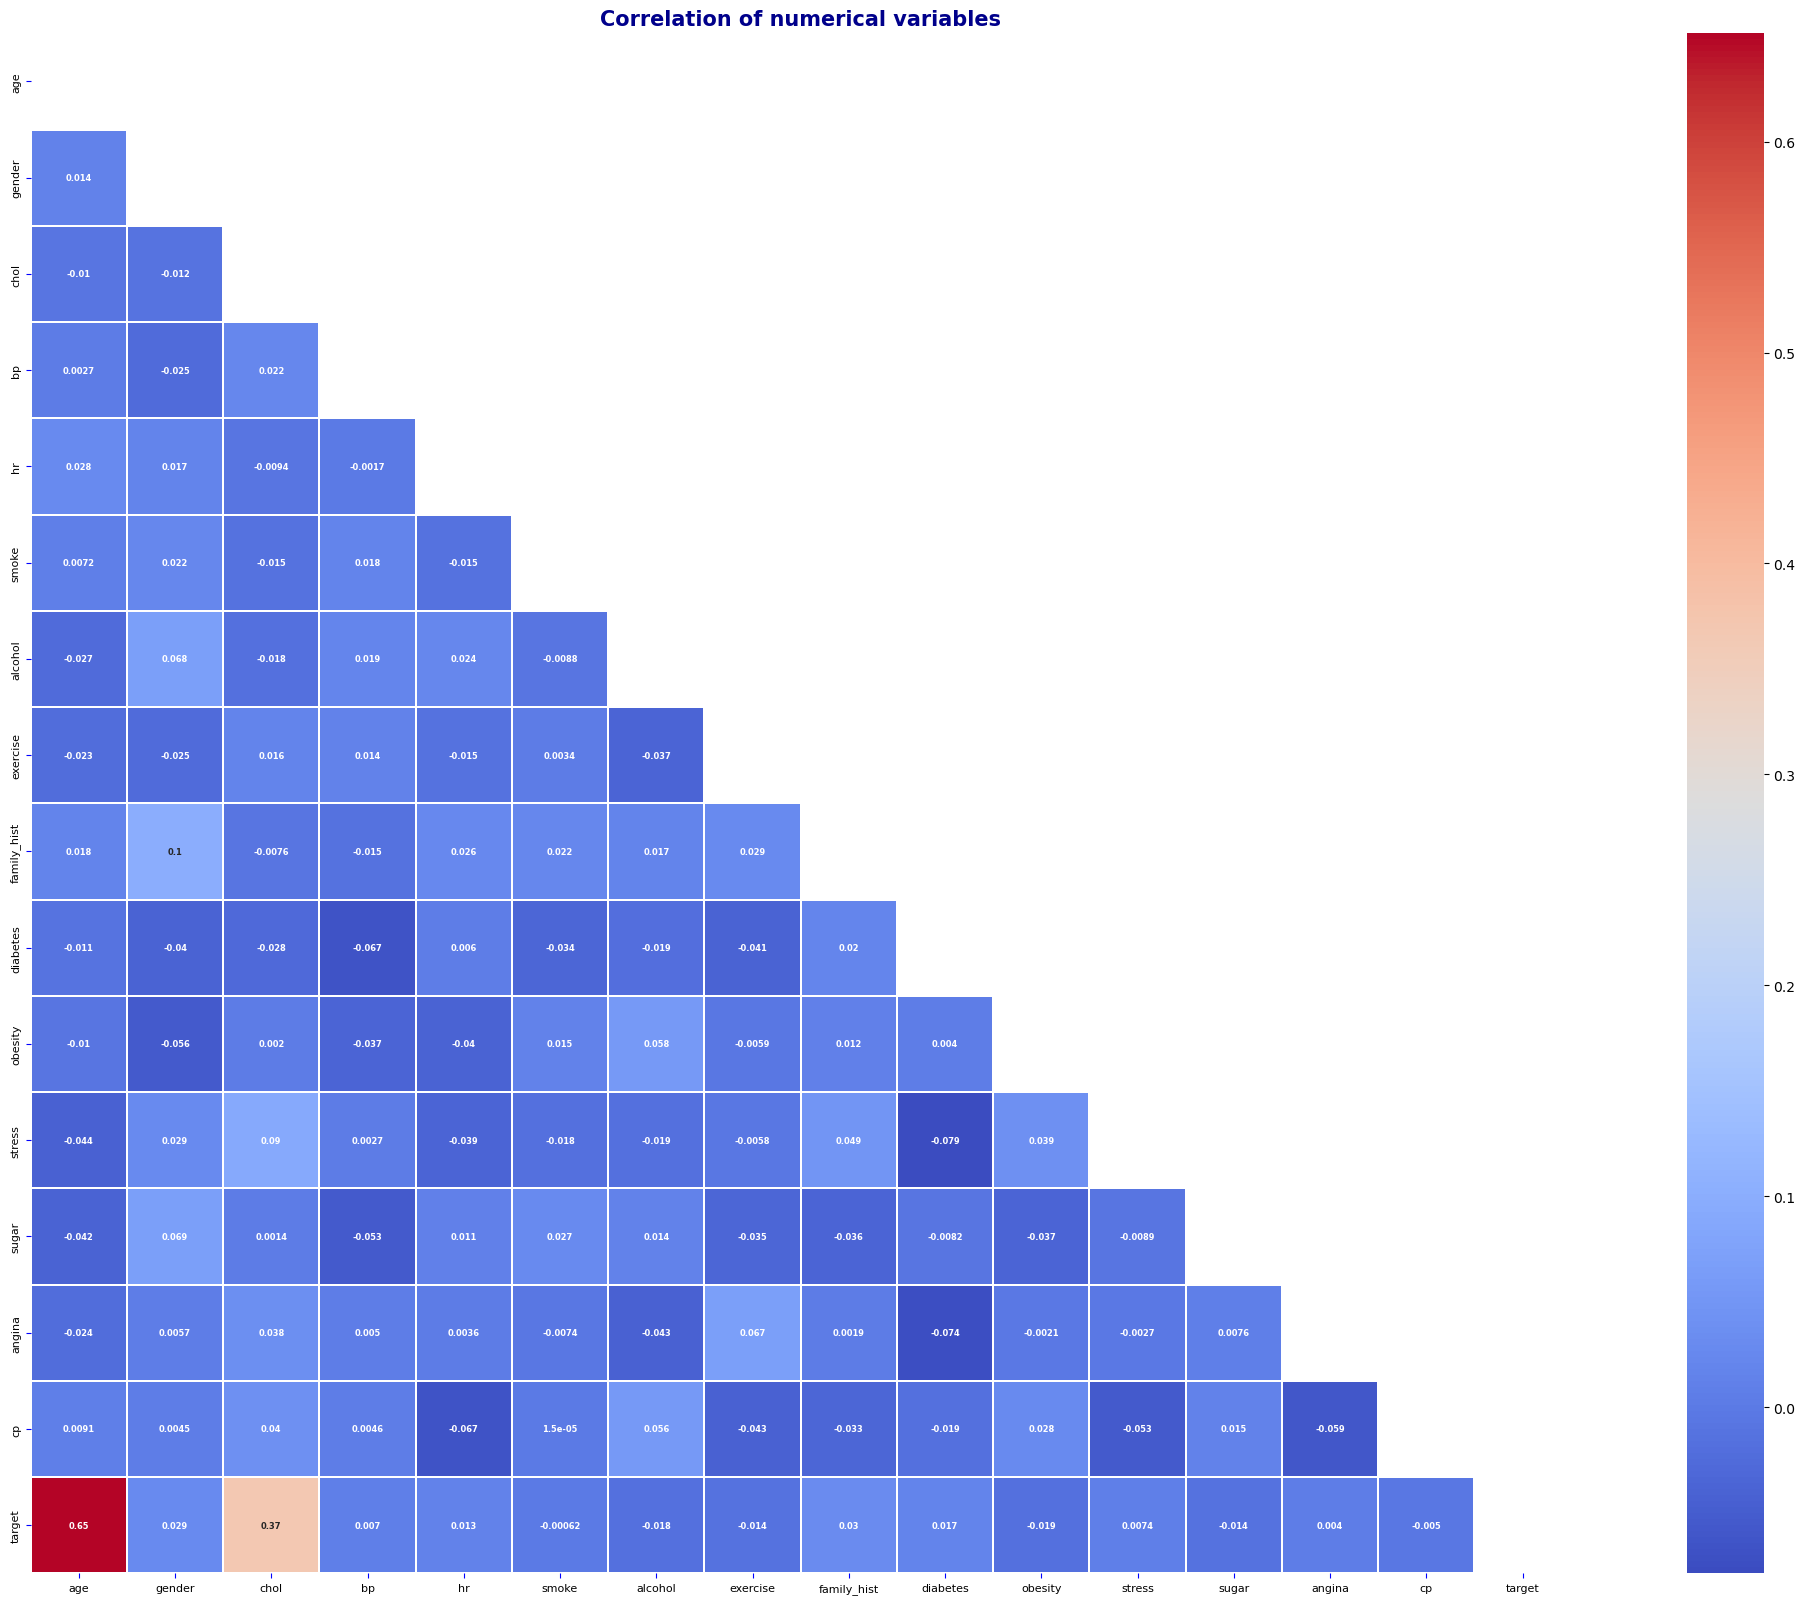

In [36]:
## Correlation plot, we use Spearman's correlation since most of the numerical variables do not come from a normal distribution,
# according to the Shapiro test that we performed.

corr_matrix = df.corr(method='spearman')
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig,ax = plt.subplots(figsize=(30,20))
sns.heatmap(corr_matrix,
            mask = mask,
            square = True,
            annot = True,
            ax = ax,
            linewidths = 0.2,
            annot_kws = {'size':6, 'fontweight':'bold'},
            cmap='coolwarm')
ax.tick_params(labelsize=8, color = 'blue', labelcolor='black')
ax.set_title('Correlation of numerical variables',fontsize = 15,fontweight='bold', color = 'darkblue')
fig.show()

In [38]:
correlation = df.corr()
target_correlation = correlation['target'].sort_values(ascending=False)
print(target_correlation)


target         1.000000
age            0.646871
chol           0.365041
family_hist    0.030283
gender         0.029399
diabetes       0.016552
hr             0.013209
stress         0.007071
bp             0.006900
angina         0.004005
smoke         -0.000539
cp            -0.005109
sugar         -0.013004
exercise      -0.014226
alcohol       -0.018183
obesity       -0.018878
Name: target, dtype: float64


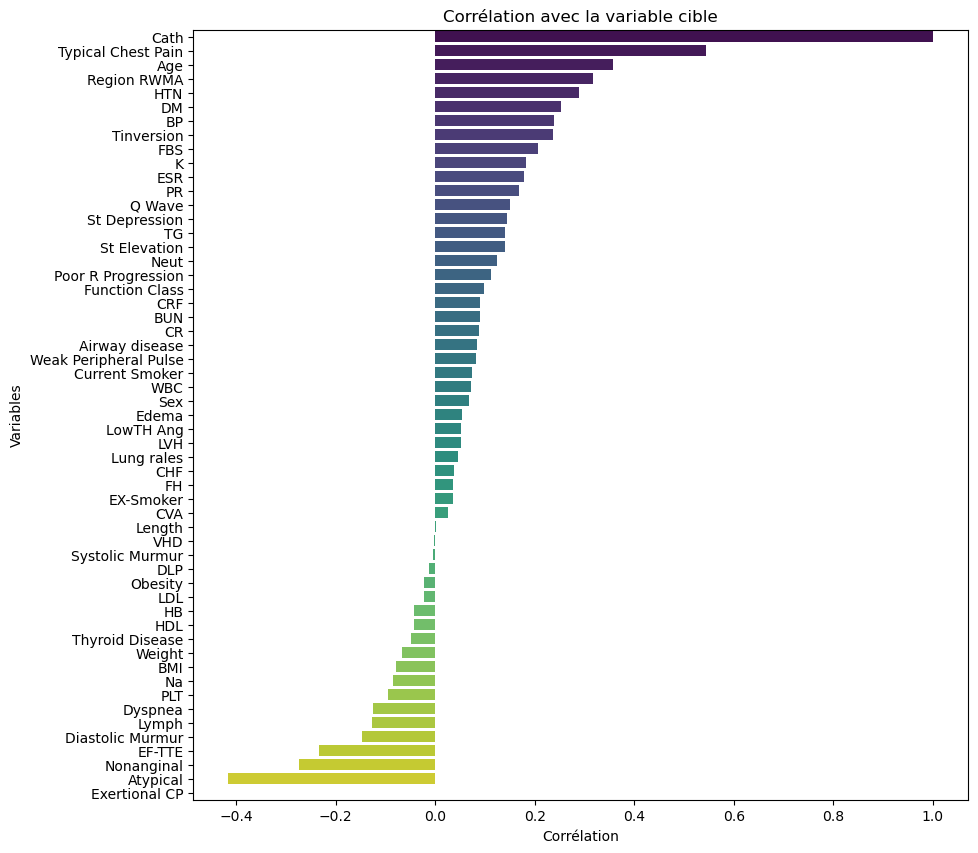

In [69]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculer la corrélation
correlation = df.corr()
target_correlation = correlation['Cath'].sort_values(ascending=False)

# Créer un graphique à barres
plt.figure(figsize=(10, 10))
sns.barplot(x=target_correlation.values, y=target_correlation.index, palette='viridis')
plt.title('Corrélation avec la variable cible')
plt.xlabel('Corrélation')
plt.ylabel('Variables')
plt.show()


In [50]:
# Everything except target variable
X = df.drop("target", axis=1) #supprimer la variable target d'un dataframe et mettre le resultet dans X

# Target variable
y = df.target.values #pour obtenir les valeurs de la variable target dans Y

In [51]:
# Independent variables (no target column)
X.head()  #afficher les 5 premiers ligne de dataset sans target

,age,gender,chol,bp,hr,smoke,alcohol,exercise,family_hist,diabetes,obesity,stress,sugar,angina,cp
0,75,0,228,119,66,2,2.0,1,0,0,1,8,119,1,1
1,48,1,204,165,62,2,0.0,5,0,0,0,9,70,1,0
2,53,1,234,91,67,0,2.0,3,1,0,1,5,196,1,1
3,69,0,192,90,72,2,0.0,4,0,1,0,7,107,1,2
4,62,0,172,163,93,0,0.0,6,0,1,0,2,183,1,3


In [52]:
# Targets
y  #afficher tous les target de dataset

array([1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0,
       1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0,
       1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0,
       0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0,
       1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1,
       0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1,
       0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1,
       0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1,
       1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,

In [53]:
random_state = 123

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=random_state)

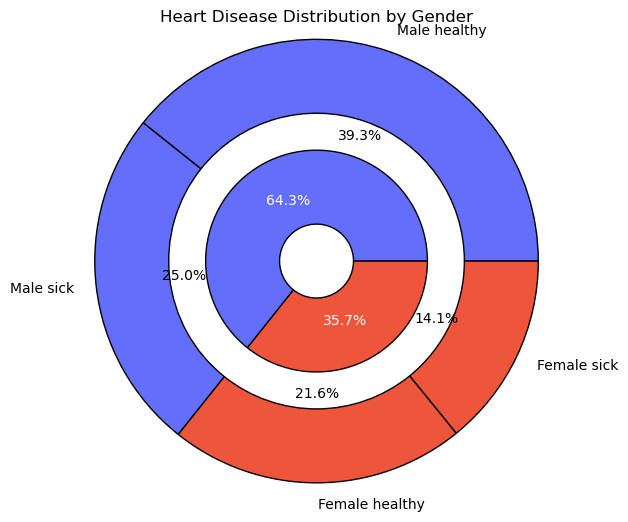

In [58]:
fig, ax = plt.subplots(figsize=(6,6))

# inner pie
ax.pie(
    inner_values,
    radius=0.6,
    colors=["#636EFA", "#EF553B"],
    autopct="%1.1f%%",
    wedgeprops=dict(width=0.4, edgecolor="black"),
    textprops={"color": "white"}
)

# outer pie
ax.pie(
    outer_values,
    radius=1.2,
    autopct="%1.1f%%",
    labels=[
        "Male healthy", "Male sick",
        "Female healthy", "Female sick"
    ],
    colors=["#636EFA", "#636EFA", "#EF553B", "#EF553B"],
    wedgeprops=dict(width=0.4, edgecolor="black")
)

ax.set_title("Heart Disease Distribution by Gender")
ax.set(aspect="equal")

plt.show()